Question 4: Backtesting

Objective: Demonstrate understanding of how to implement and backtest a trading strategy.

In [1]:
# Importing pandas for data manipulation, numpy for certain calculations, and matplotlib for visualisation:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Loading the Data from the provided CSV file, and preparing it, being aligned with the EDA carried out in Question 1, for further processing for this task:

In [2]:
df = pd.read_csv("../data/MarketData.csv", skiprows=6)

df["Dates"] = pd.to_datetime(df["Dates"], dayfirst=True)

df = df.rename(columns={
    "PX_SETTLE": "Copper",
    "PX_SETTLE.1": "Aluminum",
    "PX_SETTLE.2": "Zinc",
    "PX_SETTLE.3": "Lead",
    "PX_SETTLE.4": "Tin",
    "PX_SETTLE.5": "CL_Futures"
})

df

,Dates,Copper,Aluminum,Zinc,Lead,Tin,CL_Futures
0,2010-01-01,7375.0,2230.0,2560.0,2432.0,16950,79.36
1,2010-01-04,7500.0,2267.0,2574.0,2515.0,17450,81.51
2,2010-01-05,7485.0,2302.0,2575.0,2522.5,17375,81.77
3,2010-01-06,7660.0,2377.0,2718.0,2680.0,17825,83.18
4,2010-01-07,7535.0,2310.0,2607.0,2599.0,17475,82.66
...,...,...,...,...,...,...,...
3386,2022-12-26,8349.5,2389.5,2965.0,2273.5,23934,79.56
3387,2022-12-27,8349.5,2389.5,2965.0,2273.5,23934,79.53
3388,2022-12-28,8443.0,2381.0,3005.5,2218.0,24734,78.96
3389,2022-12-29,8418.0,2405.0,2984.5,2272.5,24915,78.40


Making a list of the assets in order to use and re-use this list in this Notebook, and making this its single source of truth, to enhance readability and maintainability. For instance, if a change needs to be made to the assets that the strategies would like to be backtested upon, then only the below line of code would need to be modified accordingly. For this task, I have chosen to backtest my two chosen strategies for all the assets in the data-set:

In [3]:
assets = ["Copper", "Aluminum", "Zinc", "Lead", "Tin", "CL_Futures"]

To view what the DataFrame df looks like at this stage:

In [4]:
df

,Dates,Copper,Aluminum,Zinc,Lead,Tin,CL_Futures
0,2010-01-01,7375.0,2230.0,2560.0,2432.0,16950,79.36
1,2010-01-04,7500.0,2267.0,2574.0,2515.0,17450,81.51
2,2010-01-05,7485.0,2302.0,2575.0,2522.5,17375,81.77
3,2010-01-06,7660.0,2377.0,2718.0,2680.0,17825,83.18
4,2010-01-07,7535.0,2310.0,2607.0,2599.0,17475,82.66
...,...,...,...,...,...,...,...
3386,2022-12-26,8349.5,2389.5,2965.0,2273.5,23934,79.56
3387,2022-12-27,8349.5,2389.5,2965.0,2273.5,23934,79.53
3388,2022-12-28,8443.0,2381.0,3005.5,2218.0,24734,78.96
3389,2022-12-29,8418.0,2405.0,2984.5,2272.5,24915,78.40


The Returns for every asset has been calculated in order to use this data as a telling factor of how much would have been gained or lost, It is calculated using the following formula:

![Percentage Change Formula](../images/Percentage_Change_Formula.png)

Wherein, the New Number is the current row's price of the asset,
and the Old Number is the row previous to the current row's price of the asset

In [5]:
for asset in assets:

    # pct_change() carries out the above percentage change formula, in order to compute the Returns for 
    # each asset as aforementioned: 
    df[f"{asset}_Returns"] = df[f"{asset}"].pct_change()

These asset Returns have been appended to the pre-processed DataFrame df as this df DataFrame will now be further used in the Backtesting of the Strategies.

Backtesting MACD strategies:

I have chosen to Backtest two MACD Strategies:

-> Crossover MACD Strategy
-> Zero-Line MACD Strategy

Making the code as efficient (vectorized) as possible:

Before implementing the strategies to be backtested, I want to first compute the MACD values for each of the 6 assets. I will be computing these and then storing them in a new DataFrame called MACD_df, as I did not want to enlarge the DataFrame df further for the purposes of maintainability, as well as to utilise the DataFrame df as the source of the actual prices and Returns solely, and be able to refer and utilise this further in this Notebook:

Please Note: MACD has been taken to be the Medium MACD of a rolling window size has been taken to be 12 for the short-term, and
a rolling window size has been taken to be 26 for the long-term. 

A Signal Line has also been computed in the calculation of the MACD values here. It is the smoother version of the MACD, allowing it to not be susceptible to the possible temporary fluctuations in the prices, and therefore, making this Signal Line being able to be used as a reference in the strategies that have been backtested in this Notebook.
The Signal Line's rolling window size has been taken as 9. 

Hence, being aligned with the standard of 26, 12 and 9 for this computation.

The Medium MACD has been chosen in order to utilise a MACD that has a more balanced sensitivity, and as it is used in general trading.

In [6]:
# Copying the Dates column from the source of truth DataFrame df, in order to maintain the Dates data in the MACD DataFrame 
# as each MACD data point is related to their corresponding Date value in the interpretation of using the MACD values in the 
# strategies in this Notebook as well:
MACD_df = df[["Dates"]].copy()

# This loop iterates over all the assets, therefore, it runs a total of 6 times here:
for asset in assets:

    # Following the manner in which MACD computation has been implemented in Question 3, the same has been followed here:

    # ewm() is used to calculate the EMA for 12 days and 26 days rolling windows respectively:
    EMA_12 = df[asset].ewm(span=12).mean()
    EMA_26 = df[asset].ewm(span=26).mean()

    # Difference between EMA for 12 days and EMA for 26 days is calculated in order to compute the MACD values here:
    MACD = EMA_12 - EMA_26

    # ewm() is used to calculate the EMA for 9 days, which constitutes the Signal Line here:
    signal = MACD.ewm(span=9).mean()

    # The MACD and Signal values for each asset are appended to the MACD_df DataFrame in order to be used and re-used in
    # the strategies that have been backtested in this Notebook following this:
    MACD_df[f"{asset}_MACD"] = MACD
    MACD_df[f"{asset}_Signal"] = signal

To view what the DataFrame MACD_df looks like at this stage:

In [7]:
MACD_df

,Dates,Copper_MACD,Copper_Signal,Aluminum_MACD,Aluminum_Signal,Zinc_MACD,Zinc_Signal,Lead_MACD,Lead_Signal,Tin_MACD,Tin_Signal,CL_Futures_MACD,CL_Futures_Signal
0,2010-01-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2010-01-04,2.804487,1.558048,0.830128,0.461182,0.314103,0.174501,1.862179,1.034544,11.217949,6.232194,0.048237,0.026798
2,2010-01-05,3.108324,2.193407,2.143096,1.150491,0.431239,0.279722,2.605361,1.678321,11.968148,8.582995,0.069526,0.044310
3,2010-01-06,9.488646,4.664694,5.395584,2.588531,5.636907,2.094486,8.566001,4.011546,28.263123,15.249705,0.128413,0.072800
4,2010-01-07,7.781821,5.591969,4.383263,3.122423,3.929972,2.640502,8.401411,5.317432,22.595253,17.434839,0.137015,0.091903
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3386,2022-12-26,67.932604,94.469076,-1.668335,9.566730,-5.919546,25.997671,33.453531,30.113747,527.184784,674.183852,-0.821309,-1.751253
3387,2022-12-27,62.696462,88.114553,-2.779531,7.097478,-12.004675,18.397202,35.964611,31.283920,494.890400,638.325162,-0.575028,-1.516008
3388,2022-12-28,65.338271,83.559296,-4.296514,4.818680,-13.404652,12.036831,33.094778,31.646092,527.766419,616.213413,-0.420989,-1.297004
3389,2022-12-29,64.669167,79.781270,-3.521540,3.150636,-16.023954,6.424674,34.816763,32.280226,561.948298,605.360390,-0.340179,-1.105639


MACD Strategies:

Crossover Strategy:

Rules:

-> When MACD is above the Signal Line, buy
-> When MACD is below the Signal Line, sell

Reasoning:

Since when the MACD is above the Signal Line, it signifies that the prices are going to rise, therefore, making this the point to buy at a lower price. Whereas, when the MACD is below the Signal Line, it signifies that the prices are going to drop, therefore, making this the point to sell at a higher price. Hence, using this strategy to maximise gains and minimise losses as much as possible through the usage of this strategy.

Zero-Line Strategy:

Compared to the Crossover Strategy, in terms of the strategy itself, this Zero-Line Strategy does not factor in the Signal Line. Instead, it uses the number 0 as a point of reference.

Rules:

-> When MACD is above 0, buy
-> When MACD is below 0, sell

Reasoning:

Since when the MACD is above 0, it means that the short-term EMA is greater than the long-term EMA, due to the formula of MACD, this therefore signifies that the overall trend is bullish at that point, hence making it a point to buy at a lower price. Similarly, since when the MACD is below 0, it means that the long-term EMA is greater than the short-term EMA, due to the same formula of MACD, this therefore signifies that the overall trend is bearish at that point, hence making it a point to sell at a higher price. Hence, using this strategy to maximise gains and minimise losses as much as possible through the usage of this strategy. 

Creating a new strategies_data DataFrame to store the data required to evaluate the performance of the Crossover and Zero-Line Strategies for backtesting, so that all the strategies data is inside one DataFrame and not merged with the provided data and their computed Returns in the DataFrame df, nor merged with DataFrame MACD_df, so that if this Notebook were to be further extended such as new Assets, or computing using the fast MACD, or the like, then only the DataFrame df, or the DataFrame MACD_df would be modified, and the other parts of this pipeline would not require as many updates and the like:

In [8]:
# strategies_data = pd.DataFrame(index=df.index)

strategies_data = df[["Dates"]].copy()

strategies = ["Crossover", "Zero_Line"]

# This nested loop iterates over both the strategies, for all the 6 assets, therefore it runs 12 times here:
for strategy in strategies:
    
    for asset in assets:

        # For both the strategies, the Output of whether to buy or sell is represented by 1 and 0 respectively:
        
        # Initialising the Output column with 0, i.e., assuming sell for all data points initially for the computation here:
        strategies_data[f"{strategy}_{asset}_Output"] = 0

        if strategy == "Crossover":

            # Implementation of the Crossover strategy, by implementing the above mentioned Rules for this strategy:
            strategies_data.loc[MACD_df[f"{asset}_MACD"] > MACD_df[f"{asset}_Signal"], f"{strategy}_{asset}_Output"] = 1
            strategies_data.loc[MACD_df[f"{asset}_MACD"] <= MACD_df[f"{asset}_Signal"], f"{strategy}_{asset}_Output"] = 0

        else:

            # Implementation of the Zero_Line strategy, by implementing the above mentioned Rules for this strategy:
            strategies_data.loc[MACD_df[f"{asset}_MACD"] > 0, f"{strategy}_{asset}_Output"] = 1
            strategies_data.loc[MACD_df[f"{asset}_MACD"] <= 0, f"{strategy}_{asset}_Output"] = 0

        # The Returns that would have resulted using the respective strategy is calculated by applying the logic that 
        # the previous day's Output of the Strategy would be applied to the current day's Return calculation, which is 
        # avoiding the look-ahead bias, i.e., via calling .shift(1). Therefore, according to whether it was buy or sell the 
        # previous day, i.e., 1 or 0 on the previous day respectively, it is multiplied by that current day's Returns as that 
        # is the gain or the loss, if this strategy would have been followed at that point of time:
        strategies_data[f"{strategy}_{asset}_Returns"] = strategies_data[f"{strategy}_{asset}_Output"].shift(1) * df[f"{asset}_Returns"]

Showing PnL, annualised sharpe ratio, and drawdown over time:

Assumption: PnL has been assumed to be the cumulative PnL. Hence, this is what has been calculated here.

Sharpe Ratio:

The following formula has been used in the calculations of Sharpe Ratio, and then annualised in this Notebook:

![Sharpe Ratio Formula](../images/Sharpe_Ratio_Formula.png)

Assumption: Risk-free Rate, i.e., R_f, is 0. This is assumed as the objective of this Notebook is to backtest the strategies and therefore, utilising this simplification to focus on the same.

Drawdown:

The following formula has been used in the calculations of Drawdown:

![Drawdown Formula](../images/Drawdown_Formula.png)

Please Note: It has been chosen to represent Drawdown values as is, instead of converting them to percentages, as they will be further used in the Notebook, following these values being computed. Additionally, mathematically, the above formula would result in 1 - (Trough Value / Peak Value), and after omitting the conversion of the values into a percentage. As a choice of convention, to have the Drawdown values be negative as this is more intuitive as the Drawdown values represent losses, the formula at this stage is flipped, and therefore, results as (Trough Value / Peak Value) - 1. Hence, this is the formula that has been implemented in computing the Drawdown below here:

Please Note: The DataFrame metrics_df is being made and used to store all the metrics data for all the 6 assets across the 2 strategies, in order to maintain that separation of concerns and enhance maintainability.

In [9]:
metrics_df = df[["Dates"]].copy()

annualised_sharpe_ratios = {}

strategies = ["Crossover", "Zero_Line"]

for strategy in strategies:

    for asset in assets:

        # PnL:
        
        # 1 is added to the Return in the numerator as this normalises to represent 100% of the initial capital in this 
        # calculation of PnL:

        # Calling cumprod() to then perform the calculation of the cumulative product on this data, as this cumulative product 
        # models how the money would have grown or shrunk over the period of time in this data here:
        metrics_df[f"{strategy}_{asset}_PnL"] = (1 + strategies_data[f"{strategy}_{asset}_Returns"]).cumprod()


        # Annualised Sharpe Ratio:

        # The Mean of the Returns, and the Standard Deviation of the Returns are calculated to apply them into the Sharpe
        # Ratio formula as depicted above:

        # The mean is used as a representation of Returns, as the numerator in the formula is applicatory for one specific value:
        mean_returns = strategies_data[f"{strategy}_{asset}_Returns"].mean()
        std_returns = strategies_data[f"{strategy}_{asset}_Returns"].std()

        # Annualising the result of applying the Sharpe Ratio with the square root of 252, as mean scales linearly with time,
        # while standard deviavtion scales with the square root of time. Therefore, since (mean / standard deviation), this
        # on scaling accordingly would be (mean * 252) / (standard deviation * square root of 252), which by the rule of 
        # exponents, would be (mean / standard deviation) * square root of 252. This has been done via calling sqrt(252):
        annualised_sharpe_ratio = (mean_returns / std_returns) * np.sqrt(252)

        # The computed annualised sharpe ratio is then stored in the annualised_sharpe_ratios dictionary for later use
        # in the Notebook:
        annualised_sharpe_ratios[f"{strategy}_{asset}"] = annualised_sharpe_ratio


        # Drawdown:

        # cummax() is called here to calculate the cumulative maximum of the PnL data, which constitues the peak here:
        peak = metrics_df[f"{strategy}_{asset}_PnL"].cummax()

        # The PnL values respectively are what constitute the trough here:
        trough = metrics_df[f"{strategy}_{asset}_PnL"]

        # The above mentioned formula is implemented here:
        metrics_df[f"{strategy}_{asset}_Drawdown"] = (trough / peak) - 1

To view what the DataFrame metrics_df looks like at this stage:

In [10]:
metrics_df

,Dates,Crossover_Copper_PnL,Crossover_Copper_Drawdown,Crossover_Aluminum_PnL,Crossover_Aluminum_Drawdown,Crossover_Zinc_PnL,Crossover_Zinc_Drawdown,Crossover_Lead_PnL,Crossover_Lead_Drawdown,Crossover_Tin_PnL,...,Zero_Line_Aluminum_PnL,Zero_Line_Aluminum_Drawdown,Zero_Line_Zinc_PnL,Zero_Line_Zinc_Drawdown,Zero_Line_Lead_PnL,Zero_Line_Lead_Drawdown,Zero_Line_Tin_PnL,Zero_Line_Tin_Drawdown,Zero_Line_CL_Futures_PnL,Zero_Line_CL_Futures_Drawdown
0,2010-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-04,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,...,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000
2,2010-01-05,0.998000,-0.002000,1.015439,0.000000,1.000389,0.000000,1.002982,0.000000,0.995702,...,1.015439,0.000000,1.000389,0.000000,1.002982,0.000000,0.995702,-0.004298,1.003190,0.000000
3,2010-01-06,1.021333,0.000000,1.048522,0.000000,1.055944,0.000000,1.065606,0.000000,1.021490,...,1.048522,0.000000,1.055944,0.000000,1.065606,0.000000,1.021490,0.000000,1.020488,0.000000
4,2010-01-07,1.004667,-0.016319,1.018968,-0.028187,1.012821,-0.040839,1.033400,-0.030224,1.001433,...,1.018968,-0.028187,1.012821,-0.040839,1.033400,-0.030224,1.001433,-0.019635,1.014109,-0.006252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3386,2022-12-26,1.008189,-0.127694,1.034027,-0.333319,1.345999,-0.169814,0.898973,-0.468081,2.029476,...,1.213819,-0.224553,0.841737,-0.297057,0.493233,-0.537134,4.031554,-0.091073,2.252389,-0.394453
3387,2022-12-27,1.008189,-0.127694,1.034027,-0.333319,1.345999,-0.169814,0.898973,-0.468081,2.029476,...,1.213819,-0.224553,0.841737,-0.297057,0.493233,-0.537134,4.031554,-0.091073,2.252389,-0.394453
3388,2022-12-28,1.008189,-0.127694,1.034027,-0.333319,1.345999,-0.169814,0.877028,-0.481066,2.029476,...,1.213819,-0.224553,0.841737,-0.297057,0.481193,-0.548433,4.166310,-0.060692,2.252389,-0.394453
3389,2022-12-29,1.008189,-0.127694,1.034027,-0.333319,1.345999,-0.169814,0.898578,-0.468315,2.029476,...,1.213819,-0.224553,0.841737,-0.297057,0.493016,-0.537337,4.196798,-0.053818,2.252389,-0.394453


To view what the Annualised Sharpe Ratios now contain after it being computed:

In [11]:
annualised_sharpe_ratios        

{'Crossover_Copper': np.float64(0.07868971484923129),
 'Crossover_Aluminum': np.float64(0.08965419255529224),
 'Crossover_Zinc': np.float64(0.21302040877210113),
 'Crossover_Lead': np.float64(0.048625851833533816),
 'Crossover_Tin': np.float64(0.40040930026625965),
 'Crossover_CL_Futures': np.float64(-0.13730648315722924),
 'Zero_Line_Copper': np.float64(0.08576601948849079),
 'Zero_Line_Aluminum': np.float64(0.17233192984133108),
 'Zero_Line_Zinc': np.float64(0.01377594549641024),
 'Zero_Line_Lead': np.float64(-0.22823481861173392),
 'Zero_Line_Tin': np.float64(0.752455730295857),
 'Zero_Line_CL_Futures': np.float64(0.37728117821855234)}

Visualisation to compare the Crossover Strategy vs. the Zero-Line Strategy:

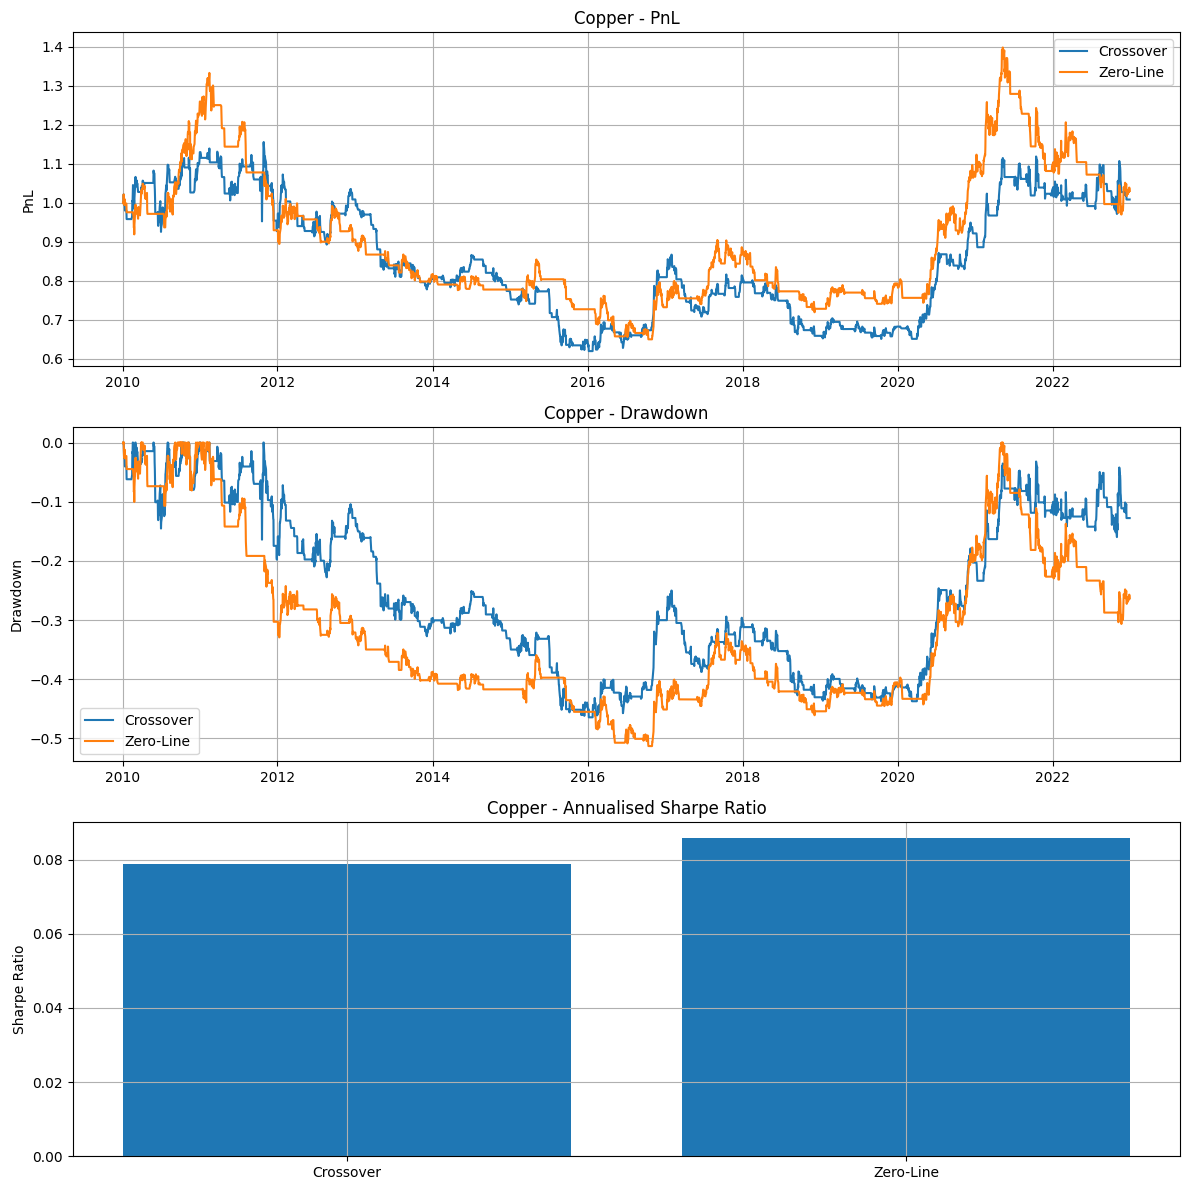

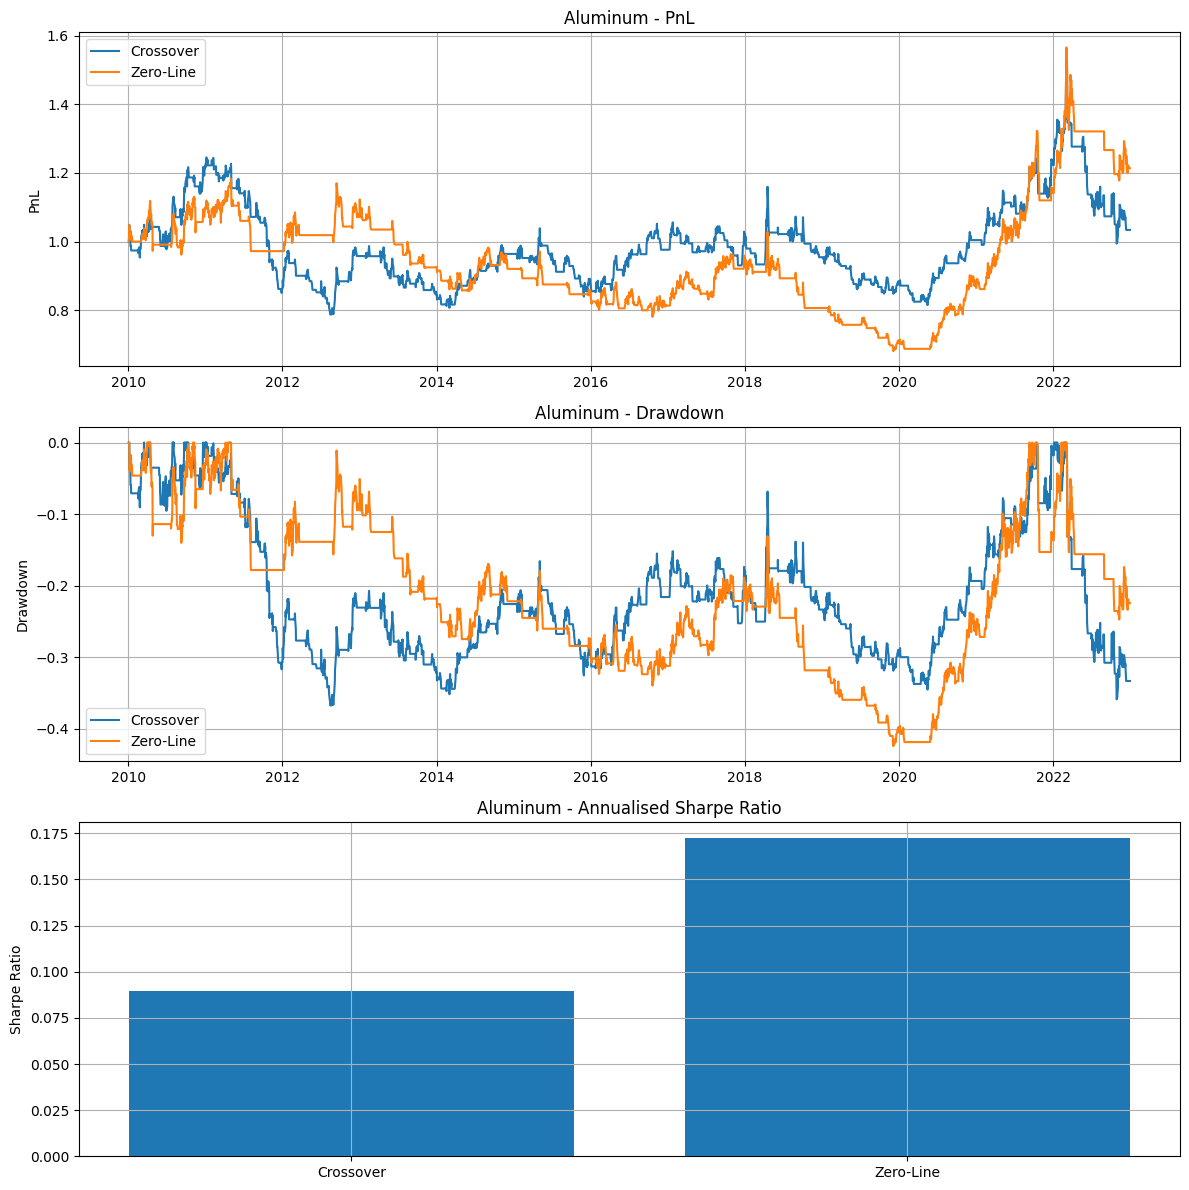

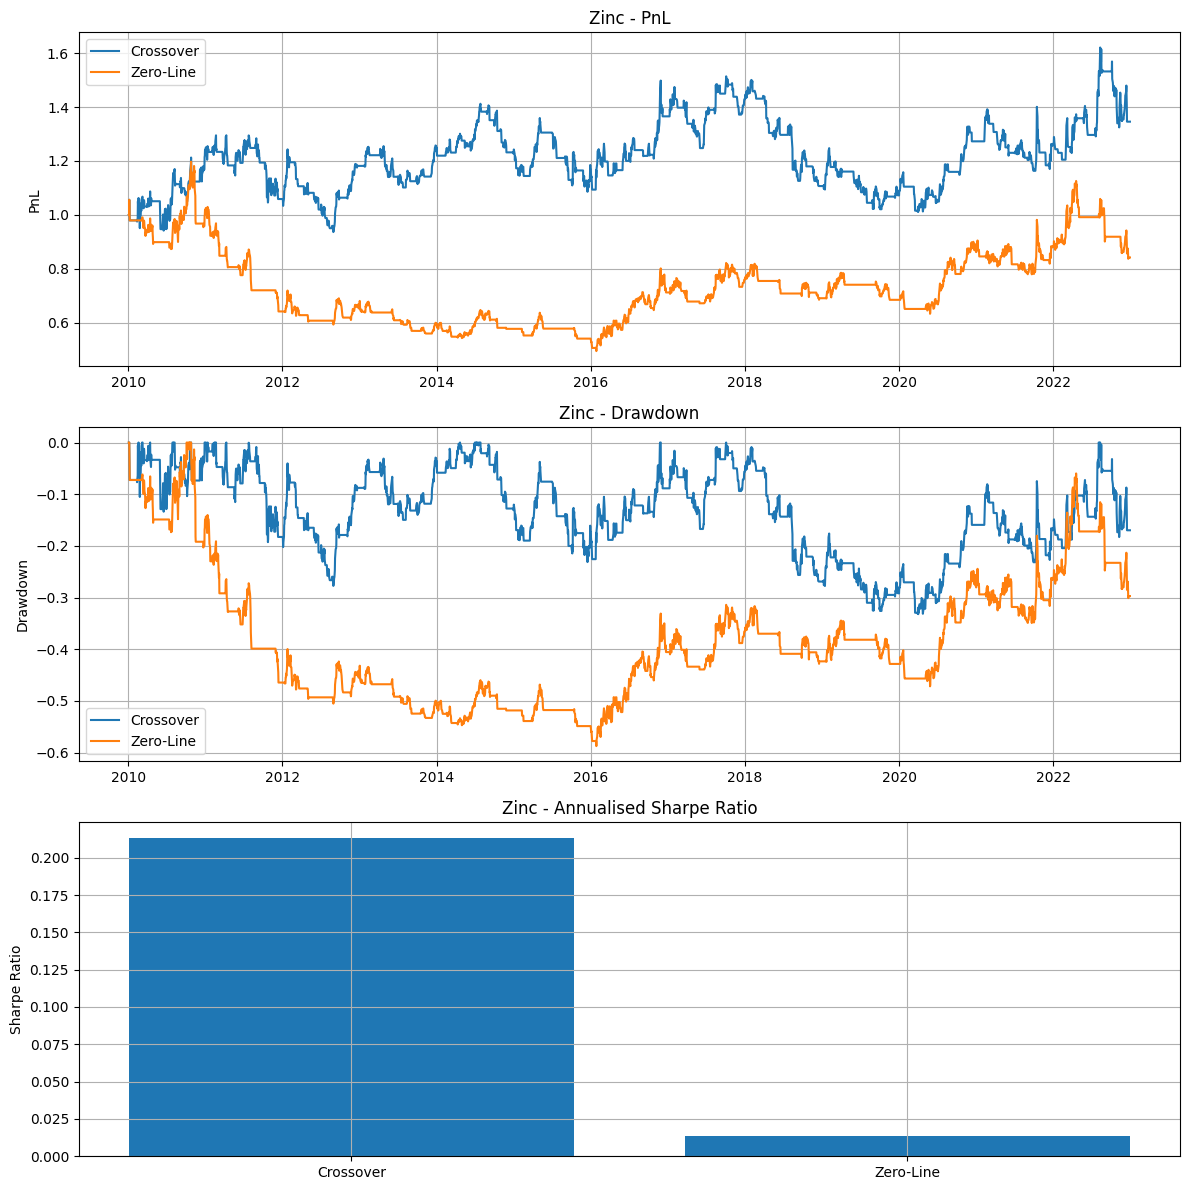

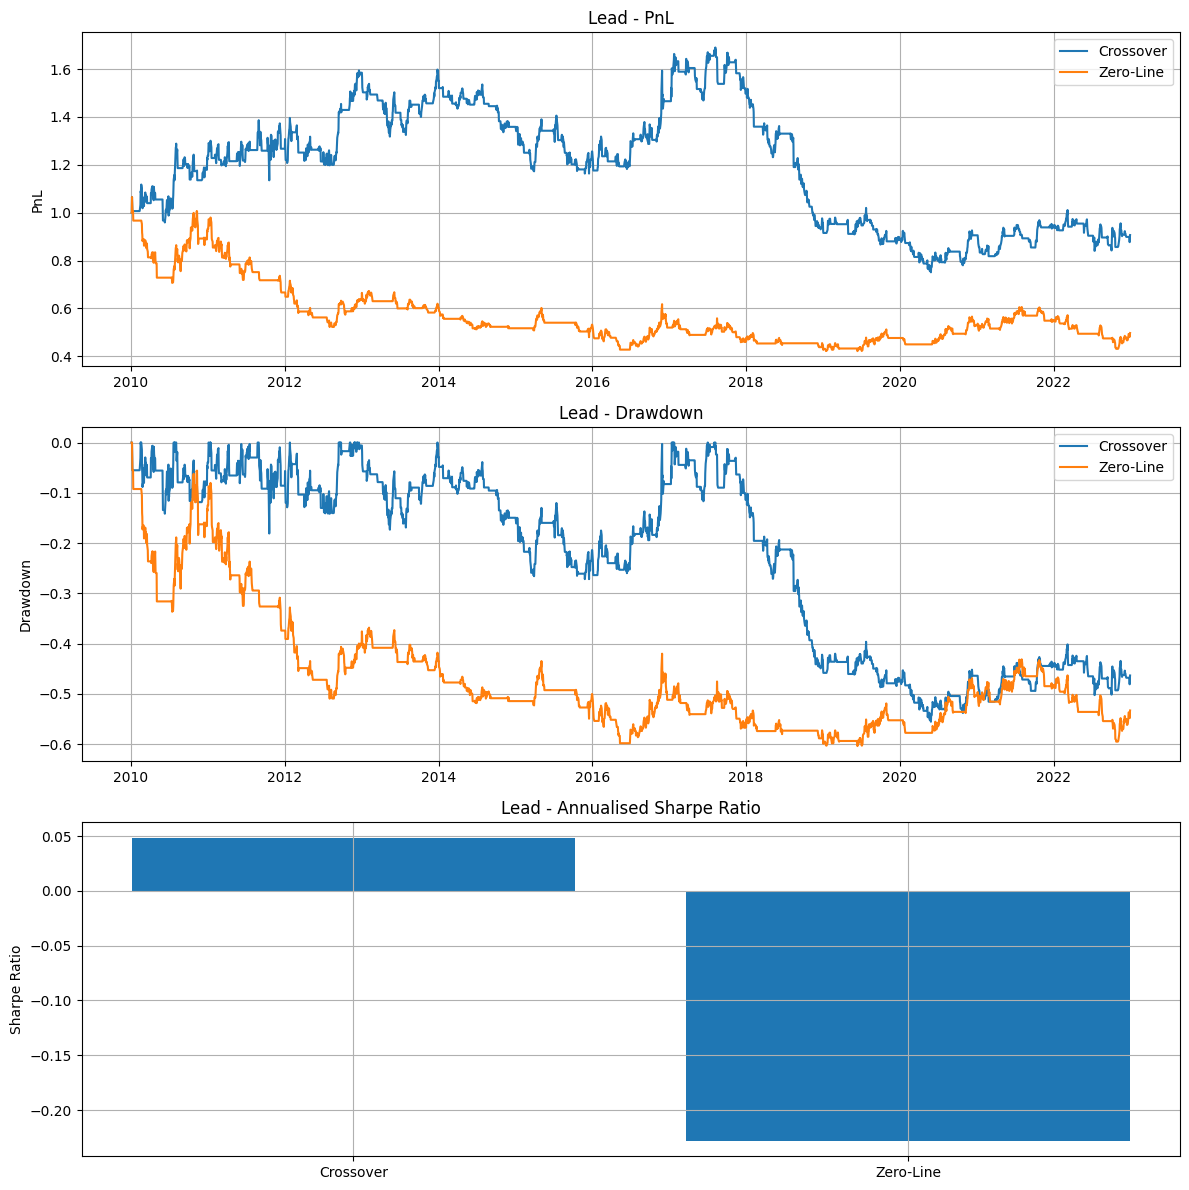

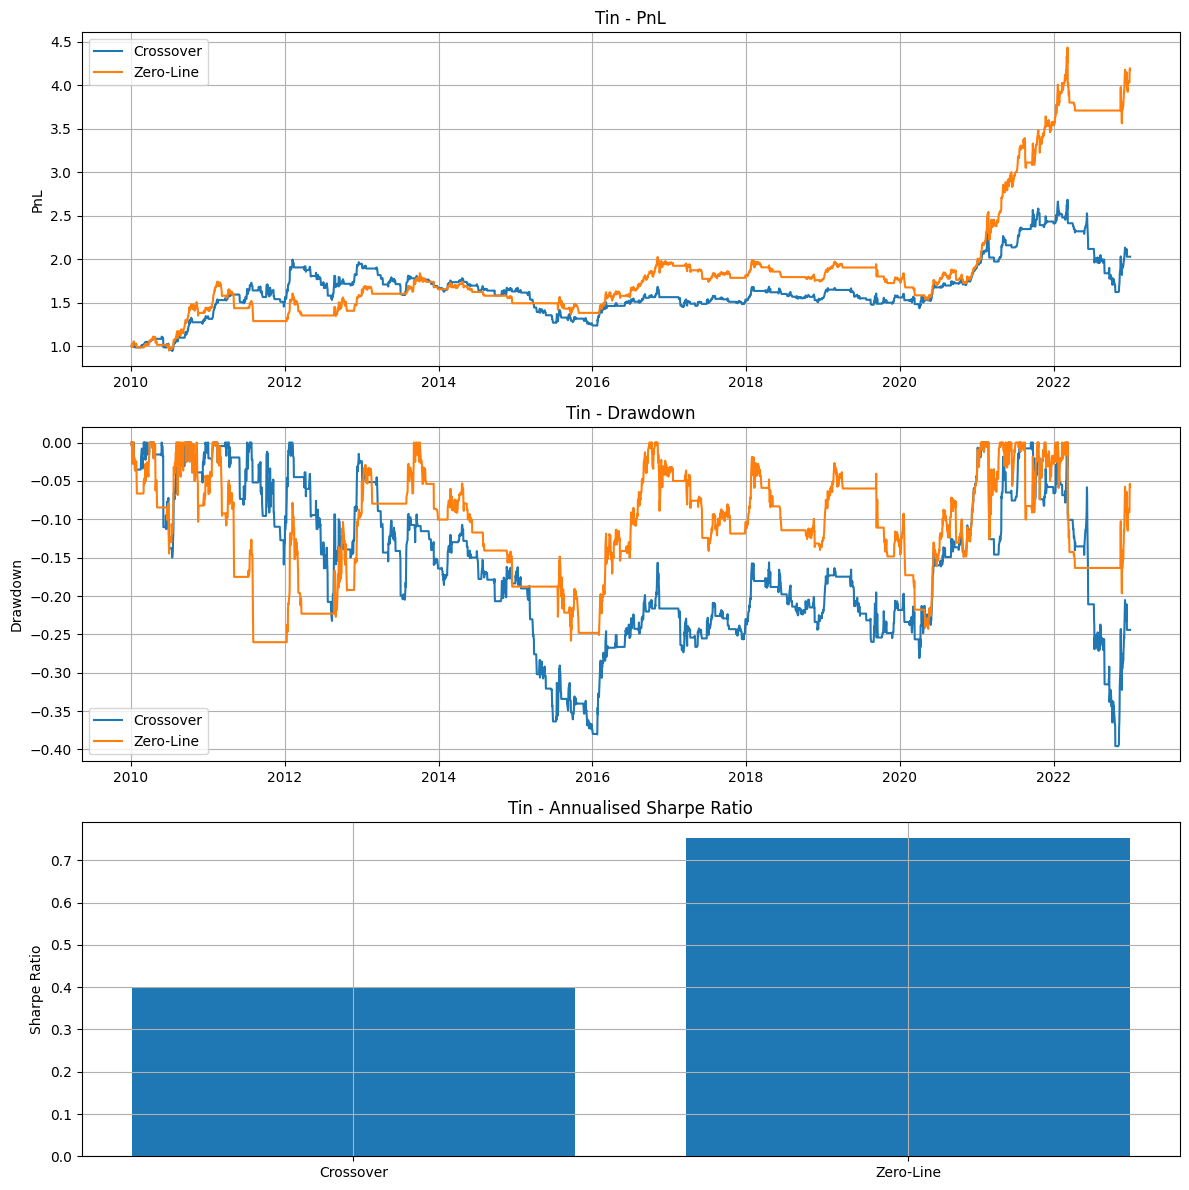

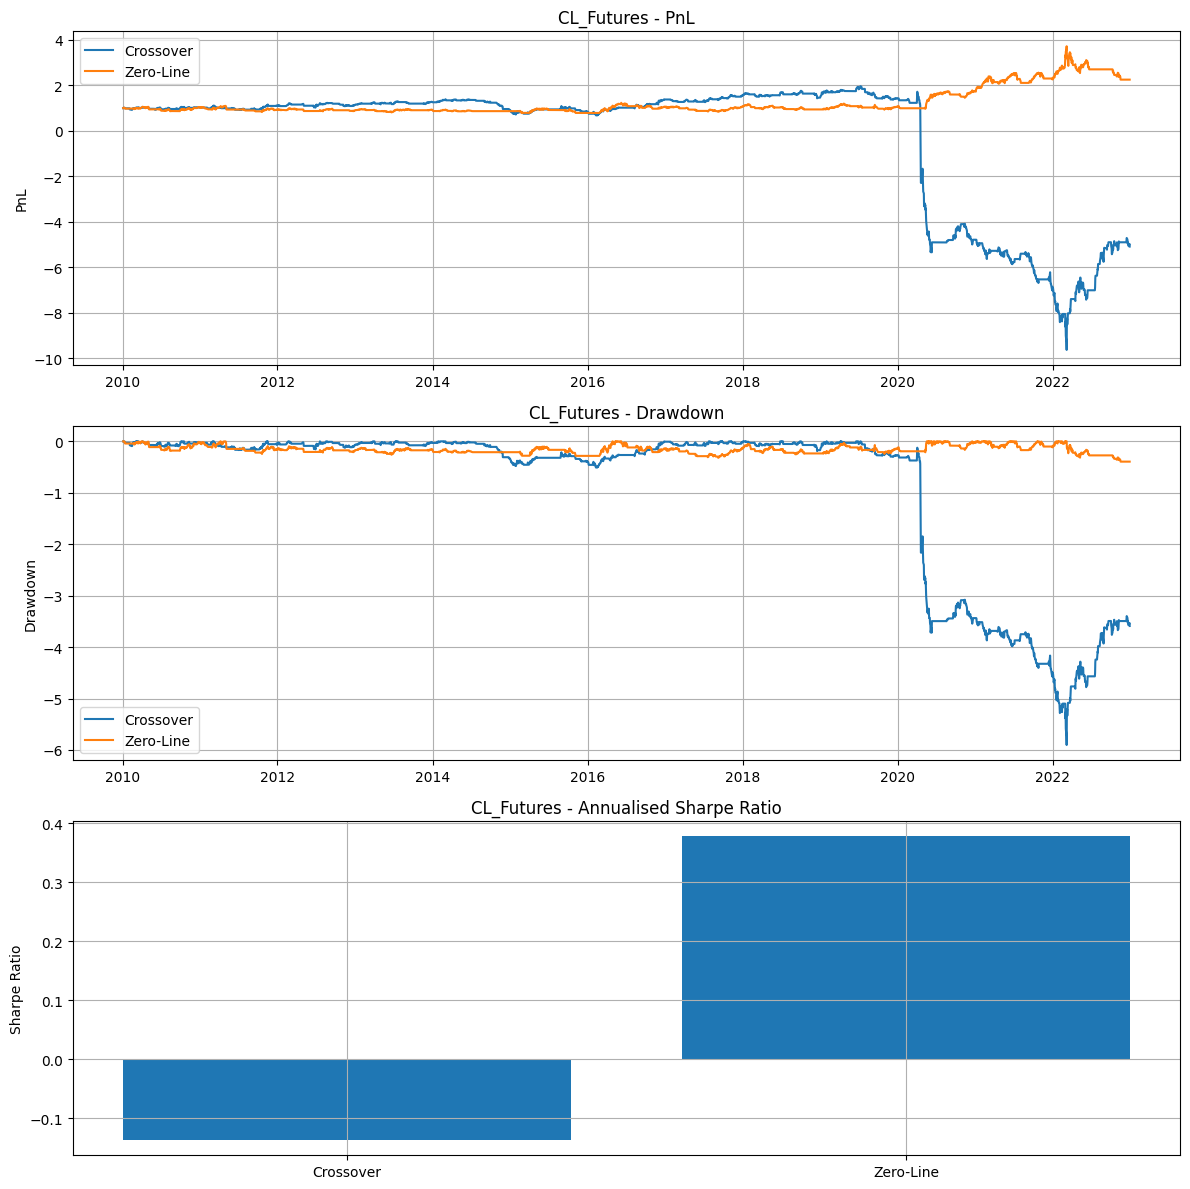

In [12]:
for asset in assets:

    fig, axes = plt.subplots(3, 1, figsize=(12, 12))


    # PnL:

    axes[0].plot(
        metrics_df["Dates"],
        metrics_df[f"Crossover_{asset}_PnL"],
        label="Crossover"
    )

    axes[0].plot(
        metrics_df["Dates"],
        metrics_df[f"Zero_Line_{asset}_PnL"],
        label="Zero-Line"
    )

    axes[0].set_title(f"{asset} - PnL")

    axes[0].set_ylabel("PnL")

    axes[0].legend()

    axes[0].grid(True)


    # Annualised Sharpe Ratio:
    
    crossover_sharpe = annualised_sharpe_ratios[f"Crossover_{asset}"]

    zero_sharpe = annualised_sharpe_ratios[f"Zero_Line_{asset}"]

    axes[2].bar(
        ["Crossover", "Zero-Line"],
        [crossover_sharpe, zero_sharpe]
    )

    axes[2].set_title(f"{asset} - Annualised Sharpe Ratio")

    axes[2].set_ylabel("Sharpe Ratio")

    axes[2].grid(True)


    # Drawdown:

    axes[1].plot(
        metrics_df["Dates"],
        metrics_df[f"Crossover_{asset}_Drawdown"],
        label="Crossover"
    )

    axes[1].plot(
        metrics_df["Dates"],
        metrics_df[f"Zero_Line_{asset}_Drawdown"],
        label="Zero-Line"
    )

    axes[1].set_title(f"{asset} - Drawdown")

    axes[1].set_ylabel("Drawdown")

    axes[1].legend()

    axes[1].grid(True)


    plt.tight_layout()

    plt.show()

While the graphs have been plotted for all 6 assets, across the 3 metrics, taking the instance of Copper for the Visualisation:

PnL: Zero-Line did reach a higher peak compared to Crossover, so Zero-Line would have performed better as for this metric here.

Drawdown: Crossover had a drawdown not as deep as Zero-Line, therefore, Crossover would have performed better as for this metric here.

Annualised Sharpe Ratio: Both are below 0.5 for this particular asset which is considered poor, although Zero-Line's Annualised Sharpe Ratio is higher than Crossover's Annualised Sharpe Ratio, therefore, Zero-Line would have performed better on this metric here.

Hence, since eventhough Zero-Line would have had deeper risks as seen from the Drawdown, it would have brought in more wealth, as seen from the PnL, and made up for those deeper risks enough to compensate accordingly, as seen from the Annualised Sharpe Ratio, as compared to the performance of the Crossover strategy here. Therefore, making the better strategy among Crossover and Zero-Line for Copper asset had these strategies been used in the period of 2010 to 2023, to be Zero-Line.


The above visualisations can hence, similarly be used to interpret their performances and then, perhaps judge which strategy of the two here would have performed better overall for this data from 2010 to 2023, as specified in the meta-data of the provided Data-Set here.

References:

-> https://www.wallstreetmojo.com/percentage-change-formula/

-> https://www.investopedia.com/terms/s/sharperatio.asp

-> https://www.investmentnews.com/glossary/drawdown/265718